In [3]:
from mplsoccer import Sbopen
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
parser = Sbopen()

competitions = parser.competition()

competitions[
    ['competition_id', 'season_id', 'competition_name', 'season_name']
].head(30)

,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
1,9,27,1. Bundesliga,2015/2016
2,1267,107,African Cup of Nations,2023
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
5,16,2,Champions League,2016/2017
6,16,27,Champions League,2015/2016
7,16,26,Champions League,2014/2015
8,16,25,Champions League,2013/2014
9,16,24,Champions League,2012/2013


In [5]:
matches = parser.match(competition_id=43, season_id=3)

matches[
    ['match_id', 'home_team_name', 'away_team_name', 'match_date']
].head()

,match_id,home_team_name,away_team_name,match_date
0,7585,Colombia,England,2018-07-03
1,7570,England,Belgium,2018-06-28
2,7586,Sweden,Switzerland,2018-07-03
3,7557,Iran,Portugal,2018-06-25
4,7542,Portugal,Morocco,2018-06-20


In [6]:
match_id = matches.iloc[0]['match_id']

events, related, freeze, tactics = parser.event(match_id)

events.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_committed_card_id,foul_committed_card_name,foul_committed_penalty,foul_won_penalty,block_offensive,substitution_replacement_id,substitution_replacement_name,shot_first_time,pass_goal_assist,shot_deflected
0,de3be98d-e227-475b-bd55-f57a6a89d308,1,1,00:00:00,0,0,1,0.000,7585,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f50ccda4-b768-4f07-9136-8f79fd17dac5,2,1,00:00:00,0,0,1,0.754,7585,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b5e98805-0a22-4a5e-a306-7d40651a0f6e,3,1,00:00:00,0,0,1,9.320,7585,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,762b829f-5f24-4dd7-bfe2-da7e289838bb,4,1,00:00:00,0,0,1,9.053,7585,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d4883f20-ce68-4f84-b26a-a049a13cb6be,5,1,00:00:00.240000,0,0,2,0.240,7585,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
events['type_name'].value_counts()

type_name
Pass               1161
Ball Receipt       1066
Carry               851
Pressure            342
Ball Recovery       113
Duel                 62
Clearance            50
Goal Keeper          44
Block                43
Shot                 41
Miscontrol           36
Foul Committed       36
Foul Won             35
Dribble              29
Camera On            20
Dribbled Past        16
Dispossessed         14
Interception         12
Half Start           10
Half End             10
Substitution          8
Injury Stoppage       6
50/50                 4
Bad Behaviour         3
Starting XI           2
Camera off            2
Player Off            1
Player On             1
Tactical Shift        1
Name: count, dtype: int64

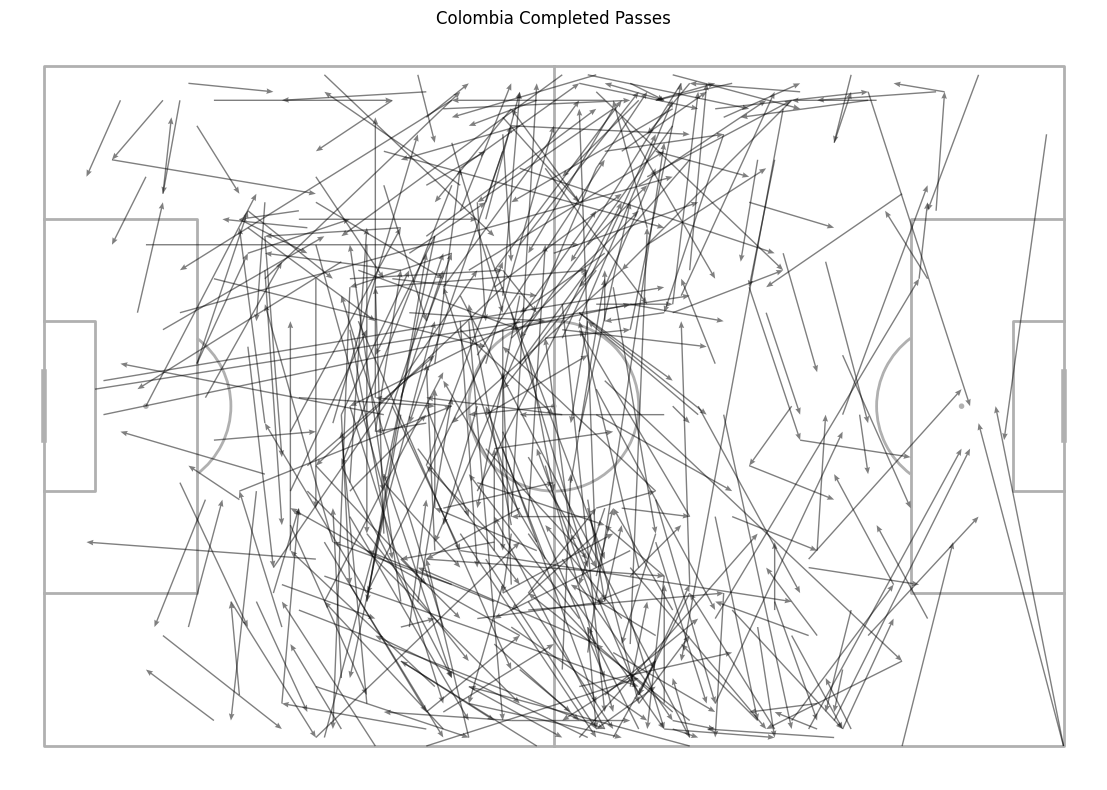

In [8]:
from mplsoccer import Pitch

passes = events[events['type_name'] == 'Pass'].copy()

team = passes['team_name'].dropna().unique()[0]

team_passes = passes[
    (passes['team_name'] == team) &
    (passes['outcome_name'].isna())
]

pitch = Pitch(pitch_type='statsbomb')

fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    team_passes['x'],
    team_passes['y'],
    team_passes['end_x'],
    team_passes['end_y'],
    ax=ax,
    width=1,
    headwidth=4,
    alpha=0.5
)

ax.set_title(f'{team} Completed Passes')

plt.show()

In [9]:
events[['x', 'y', 'end_x', 'end_y']].describe()

,x,y,end_x,end_y
count,3955.000000,3955.000000,2078.000000,2078.000000
mean,56.755752,39.800000,61.583734,39.049326
std,27.563529,23.122011,28.052198,22.812812
min,1.000000,1.000000,1.000000,1.000000
25%,35.000000,20.000000,40.000000,20.000000
50%,55.000000,40.000000,61.000000,40.000000
75%,77.000000,60.000000,83.000000,58.000000
max,120.000000,80.000000,120.000000,80.000000


In [10]:
passes['progress_distance'] = passes['end_x'] - passes['x']

passes[
    [
        'player_name',
        'x',
        'end_x',
        'progress_distance'
    ]
].head()

,player_name,x,end_x,progress_distance
4,Radamel Falcao García Zárate,60.0,50.0,-10.0
8,Juan Fernando Quintero Paniagua,51.0,47.0,-4.0
11,Carlos Alberto Sánchez Moreno,49.0,65.0,16.0
15,Santiago Arias Naranjo,66.0,96.0,30.0
16,Harry Maguire,25.0,32.0,7.0


In [11]:
progressive = passes.sort_values(
    'progress_distance',
    ascending=False
)

progressive[
    [
        'player_name',
        'team_name',
        'x',
        'end_x',
        'progress_distance'
    ]
].head(20)

,player_name,team_name,x,end_x,progress_distance
1648,Jordan Pickford,England,27.0,120.0,93.0
3879,Jordan Pickford,England,6.0,90.0,84.0
2755,Jordan Pickford,England,7.0,85.0,78.0
1181,Carlos Alberto Sánchez Moreno,Colombia,38.0,115.0,77.0
191,David Ospina Ramírez,Colombia,17.0,93.0,76.0
3931,Jordan Pickford,England,19.0,94.0,75.0
2955,Ashley Young,England,31.0,106.0,75.0
1978,David Ospina Ramírez,Colombia,9.0,83.0,74.0
2885,John Stones,England,45.0,119.0,74.0
2306,Jordan Pickford,England,13.0,85.0,72.0


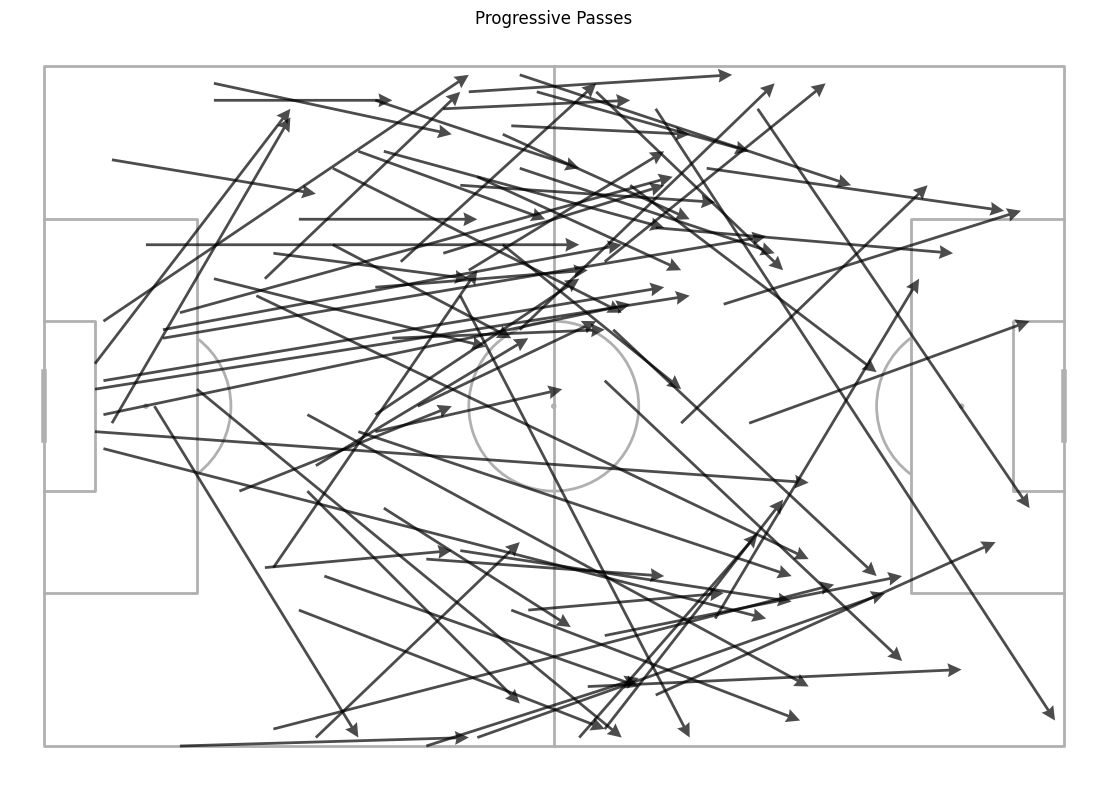

In [12]:
from mplsoccer import Pitch

prog_passes = passes[
    (passes['progress_distance'] > 20) &
    (passes['outcome_name'].isna())
]

pitch = Pitch(pitch_type='statsbomb')

fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    prog_passes['x'],
    prog_passes['y'],
    prog_passes['end_x'],
    prog_passes['end_y'],
    ax=ax,
    width=2,
    headwidth=5,
    alpha=0.7
)

ax.set_title('Progressive Passes')

plt.show()


In [13]:
import numpy as np

# Divide pitch into 6 vertical zones
passes['start_zone'] = (passes['x'] // 20).astype(int)
passes['end_zone'] = (passes['end_x'] // 20).astype(int)

passes[
    [
        'player_name',
        'x',
        'end_x',
        'start_zone',
        'end_zone'
    ]
].head(20)

,player_name,x,end_x,start_zone,end_zone
4,Radamel Falcao García Zárate,60.0,50.0,3,2
8,Juan Fernando Quintero Paniagua,51.0,47.0,2,2
11,Carlos Alberto Sánchez Moreno,49.0,65.0,2,3
15,Santiago Arias Naranjo,66.0,96.0,3,4
16,Harry Maguire,25.0,32.0,1,1
19,Bamidele Alli,32.0,25.0,1,1
23,Juan Guillermo Cuadrado Bello,95.0,92.0,4,4
27,Santiago Arias Naranjo,89.0,90.0,4,4
32,Jesse Lingard,32.0,36.0,1,1
36,Bamidele Alli,36.0,43.0,1,2


In [14]:
zone_values = {
    0: 0.01,
    1: 0.03,
    2: 0.06,
    3: 0.12,
    4: 0.20,
    5: 0.40
}

passes['start_xT'] = passes['start_zone'].map(zone_values)
passes['end_xT'] = passes['end_zone'].map(zone_values)

passes['xT_added'] = passes['end_xT'] - passes['start_xT']

passes[
    [
        'player_name',
        'x',
        'end_x',
        'start_xT',
        'end_xT',
        'xT_added'
    ]
].head(20)

,player_name,x,end_x,start_xT,end_xT,xT_added
4,Radamel Falcao García Zárate,60.0,50.0,0.12,0.06,-0.06
8,Juan Fernando Quintero Paniagua,51.0,47.0,0.06,0.06,0.00
11,Carlos Alberto Sánchez Moreno,49.0,65.0,0.06,0.12,0.06
15,Santiago Arias Naranjo,66.0,96.0,0.12,0.20,0.08
16,Harry Maguire,25.0,32.0,0.03,0.03,0.00
19,Bamidele Alli,32.0,25.0,0.03,0.03,0.00
23,Juan Guillermo Cuadrado Bello,95.0,92.0,0.20,0.20,0.00
27,Santiago Arias Naranjo,89.0,90.0,0.20,0.20,0.00
32,Jesse Lingard,32.0,36.0,0.03,0.03,0.00
36,Bamidele Alli,36.0,43.0,0.03,0.06,0.03


In [15]:
best_xt = passes.sort_values(
    'xT_added',
    ascending=False
)

best_xt[
    [
        'player_name',
        'team_name',
        'x',
        'end_x',
        'xT_added'
    ]
].head(20)

,player_name,team_name,x,end_x,xT_added
1181,Carlos Alberto Sánchez Moreno,Colombia,38.0,115.0,0.37
2955,Ashley Young,England,31.0,106.0,0.37
2885,John Stones,England,45.0,119.0,0.34
1516,Jefferson Andrés Lerma Solís,Colombia,57.0,104.0,0.34
3594,Carlos Arturo Bacca Ahumada,Colombia,58.0,100.0,0.34
1148,Ashley Young,England,55.0,105.0,0.34
2149,Harry Maguire,England,59.0,105.0,0.34
1938,Ashley Young,England,70.0,103.0,0.28
425,Kieran Trippier,England,78.0,112.0,0.28
1461,Jefferson Andrés Lerma Solís,Colombia,71.0,104.0,0.28


In [16]:
# Create x and y bins
passes['x_bin'] = (passes['x'] // 20).astype(int)
passes['y_bin'] = (passes['y'] // 20).astype(int)

passes['end_x_bin'] = (passes['end_x'] // 20).astype(int)
passes['end_y_bin'] = (passes['end_y'] // 20).astype(int)

passes[
    [
        'x',
        'y',
        'x_bin',
        'y_bin'
    ]
].head()

,x,y,x_bin,y_bin
4,60.0,40.0,3,2
8,51.0,40.0,2,2
11,49.0,55.0,2,2
15,66.0,78.0,3,3
16,25.0,22.0,1,1


In [17]:
# Simple 6x4 xT grid
xT_grid = np.array([
    [0.01, 0.01, 0.01, 0.01],
    [0.02, 0.03, 0.03, 0.02],
    [0.04, 0.06, 0.06, 0.04],
    [0.08, 0.12, 0.12, 0.08],
    [0.12, 0.20, 0.20, 0.12],
    [0.18, 0.40, 0.40, 0.18]
])

In [18]:
passes['start_xT'] = passes.apply(
    lambda row: xT_grid[
        min(row['x_bin'], 5),
        min(row['y_bin'], 3)
    ],
    axis=1
)

passes['end_xT'] = passes.apply(
    lambda row: xT_grid[
        min(row['end_x_bin'], 5),
        min(row['end_y_bin'], 3)
    ],
    axis=1
)

passes['xT_added'] = passes['end_xT'] - passes['start_xT']

passes[
    [
        'player_name',
        'x',
        'y',
        'end_x',
        'end_y',
        'start_xT',
        'end_xT',
        'xT_added'
    ]
].head(20)

,player_name,x,y,end_x,end_y,start_xT,end_xT,xT_added
4,Radamel Falcao García Zárate,60.0,40.0,50.0,41.0,0.12,0.06,-0.06
8,Juan Fernando Quintero Paniagua,51.0,40.0,47.0,54.0,0.06,0.06,0.00
11,Carlos Alberto Sánchez Moreno,49.0,55.0,65.0,79.0,0.06,0.08,0.02
15,Santiago Arias Naranjo,66.0,78.0,96.0,59.0,0.08,0.20,0.12
16,Harry Maguire,25.0,22.0,32.0,2.0,0.03,0.02,-0.01
19,Bamidele Alli,32.0,2.0,25.0,17.0,0.02,0.02,0.00
23,Juan Guillermo Cuadrado Bello,95.0,64.0,92.0,76.0,0.12,0.12,0.00
27,Santiago Arias Naranjo,89.0,66.0,90.0,52.0,0.12,0.20,0.08
32,Jesse Lingard,32.0,26.0,36.0,28.0,0.03,0.03,0.00
36,Bamidele Alli,36.0,19.0,43.0,6.0,0.02,0.04,0.02


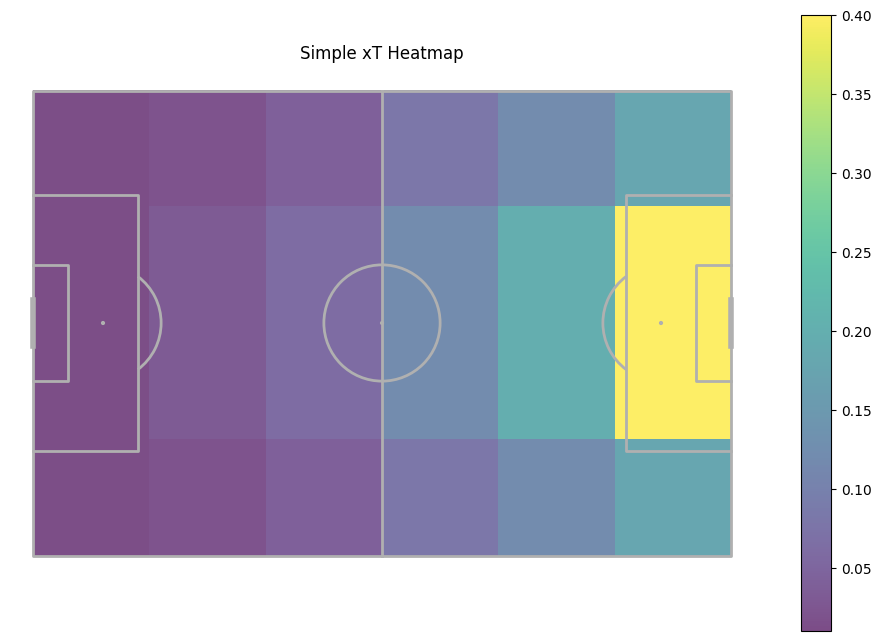

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

pitch = Pitch(pitch_type='statsbomb')

pitch.draw(ax=ax)

heatmap = ax.imshow(
    xT_grid.T,
    extent=[0, 120, 0, 80],
    origin='lower',
    alpha=0.7
)

plt.colorbar(heatmap)

ax.set_title('Simple xT Heatmap')

plt.show()

In [20]:
# Only completed passes
completed_passes = passes[passes['outcome_name'].isna()].copy()

player_xt = (
    completed_passes
    .groupby(['player_name', 'team_name'], as_index=False)
    .agg(
        total_xT=('xT_added', 'sum'),
        actions=('xT_added', 'count'),
        avg_xT_per_pass=('xT_added', 'mean')
    )
    .sort_values('total_xT', ascending=False)
)

player_xt.head(20)

,player_name,team_name,total_xT,actions,avg_xT_per_pass
20,Juan Guillermo Cuadrado Bello,Colombia,1.99,48,0.041458
21,Kieran Trippier,England,1.50,35,0.042857
11,Harry Maguire,England,1.32,67,0.019701
18,Jordan Pickford,England,1.24,31,0.040000
1,Ashley Young,England,1.20,29,0.041379
8,Davinson Sánchez Mina,Colombia,0.94,54,0.017407
16,John Stones,England,0.82,76,0.010789
15,Johan Andrés Mojica Palacio,Colombia,0.60,45,0.013333
19,Juan Fernando Quintero Paniagua,Colombia,0.58,29,0.020000
3,Carlos Alberto Sánchez Moreno,Colombia,0.53,32,0.016563


In [21]:
team_xt = (
    completed_passes
    .groupby('team_name', as_index=False)
    .agg(
        total_xT=('xT_added', 'sum'),
        actions=('xT_added', 'count'),
        avg_xT_per_pass=('xT_added', 'mean')
    )
    .sort_values('total_xT', ascending=False)
)

team_xt

,team_name,total_xT,actions,avg_xT_per_pass
1,England,7.44,477,0.015597
0,Colombia,5.04,429,0.011748


In [22]:
carries = events[events['type_name'] == 'Carry'].copy()

carries[
    [
        'player_name',
        'team_name',
        'x',
        'y',
        'end_x',
        'end_y'
    ]
].head()

,player_name,team_name,x,y,end_x,end_y
6,Juan Fernando Quintero Paniagua,Colombia,50.0,41.0,51.0,40.0
10,Carlos Alberto Sánchez Moreno,Colombia,47.0,54.0,49.0,55.0
13,Santiago Arias Naranjo,Colombia,65.0,79.0,66.0,78.0
22,Juan Guillermo Cuadrado Bello,Colombia,96.0,64.0,95.0,64.0
26,Santiago Arias Naranjo,Colombia,92.0,76.0,89.0,66.0


In [23]:
carries['x_bin'] = (carries['x'] // 20).astype(int)
carries['y_bin'] = (carries['y'] // 20).astype(int)

carries['end_x_bin'] = (carries['end_x'] // 20).astype(int)
carries['end_y_bin'] = (carries['end_y'] // 20).astype(int)

In [24]:
carries['start_xT'] = carries.apply(
    lambda row: xT_grid[
        min(row['x_bin'], 5),
        min(row['y_bin'], 3)
    ],
    axis=1
)

carries['end_xT'] = carries.apply(
    lambda row: xT_grid[
        min(row['end_x_bin'], 5),
        min(row['end_y_bin'], 3)
    ],
    axis=1
)

carries['xT_added'] = carries['end_xT'] - carries['start_xT']

carries[
    [
        'player_name',
        'team_name',
        'x',
        'y',
        'end_x',
        'end_y',
        'start_xT',
        'end_xT',
        'xT_added'
    ]
].head(20)

,player_name,team_name,x,y,end_x,end_y,start_xT,end_xT,xT_added
6,Juan Fernando Quintero Paniagua,Colombia,50.0,41.0,51.0,40.0,0.06,0.06,0.00
10,Carlos Alberto Sánchez Moreno,Colombia,47.0,54.0,49.0,55.0,0.06,0.06,0.00
13,Santiago Arias Naranjo,Colombia,65.0,79.0,66.0,78.0,0.08,0.08,0.00
22,Juan Guillermo Cuadrado Bello,Colombia,96.0,64.0,95.0,64.0,0.12,0.12,0.00
26,Santiago Arias Naranjo,Colombia,92.0,76.0,89.0,66.0,0.12,0.12,0.00
30,Jesse Lingard,England,31.0,29.0,32.0,26.0,0.03,0.03,0.00
34,Bamidele Alli,England,36.0,28.0,36.0,19.0,0.03,0.02,-0.01
39,Harry Kane,England,43.0,6.0,42.0,3.0,0.04,0.04,0.00
44,Davinson Sánchez Mina,Colombia,35.0,27.0,36.0,31.0,0.03,0.03,0.00
47,Yerry Fernando Mina González,Colombia,41.0,58.0,42.0,58.0,0.06,0.06,0.00


In [25]:
completed_passes = passes[passes['outcome_name'].isna()].copy()

pass_xt = completed_passes[
    ['player_name', 'team_name', 'xT_added']
].copy()
pass_xt['action_type'] = 'Pass'

carry_xt = carries[
    ['player_name', 'team_name', 'xT_added']
].copy()
carry_xt['action_type'] = 'Carry'

all_xt_actions = pd.concat([pass_xt, carry_xt], ignore_index=True)

all_xt_actions.head()

,player_name,team_name,xT_added,action_type
0,Radamel Falcao García Zárate,Colombia,-0.06,Pass
1,Juan Fernando Quintero Paniagua,Colombia,0.00,Pass
2,Carlos Alberto Sánchez Moreno,Colombia,0.02,Pass
3,Harry Maguire,England,-0.01,Pass
4,Juan Guillermo Cuadrado Bello,Colombia,0.00,Pass


In [26]:
player_total_xt = (
    all_xt_actions
    .groupby(['player_name', 'team_name'], as_index=False)
    .agg(
        total_xT=('xT_added', 'sum'),
        actions=('xT_added', 'count'),
        avg_xT_per_action=('xT_added', 'mean')
    )
    .sort_values('total_xT', ascending=False)
)

player_total_xt.head(20)

,player_name,team_name,total_xT,actions,avg_xT_per_action
20,Juan Guillermo Cuadrado Bello,Colombia,1.99,108,0.018426
21,Kieran Trippier,England,1.57,58,0.027069
11,Harry Maguire,England,1.54,116,0.013276
16,John Stones,England,1.34,143,0.009371
18,Jordan Pickford,England,1.26,59,0.021356
1,Ashley Young,England,1.22,54,0.022593
15,Johan Andrés Mojica Palacio,Colombia,1.19,96,0.012396
19,Juan Fernando Quintero Paniagua,Colombia,0.93,66,0.014091
8,Davinson Sánchez Mina,Colombia,0.86,105,0.008190
22,Kyle Walker,England,0.85,105,0.008095


In [27]:
player_xt_by_type = (
    all_xt_actions
    .groupby(['player_name', 'team_name', 'action_type'], as_index=False)
    .agg(
        total_xT=('xT_added', 'sum'),
        actions=('xT_added', 'count')
    )
)

player_xt_pivot = player_xt_by_type.pivot_table(
    index=['player_name', 'team_name'],
    columns='action_type',
    values='total_xT',
    fill_value=0
).reset_index()

player_xt_pivot['total_xT'] = (
    player_xt_pivot.get('Pass', 0) + 
    player_xt_pivot.get('Carry', 0)
)

player_xt_pivot.sort_values('total_xT', ascending=False).head(20)

action_type,player_name,team_name,Carry,Pass,total_xT
20,Juan Guillermo Cuadrado Bello,Colombia,-4.163336e-17,1.99,1.99
21,Kieran Trippier,England,7.000000e-02,1.50,1.57
11,Harry Maguire,England,2.200000e-01,1.32,1.54
16,John Stones,England,5.200000e-01,0.82,1.34
18,Jordan Pickford,England,2.000000e-02,1.24,1.26
1,Ashley Young,England,2.000000e-02,1.20,1.22
15,Johan Andrés Mojica Palacio,Colombia,5.900000e-01,0.60,1.19
19,Juan Fernando Quintero Paniagua,Colombia,3.500000e-01,0.58,0.93
8,Davinson Sánchez Mina,Colombia,-8.000000e-02,0.94,0.86
22,Kyle Walker,England,4.900000e-01,0.36,0.85


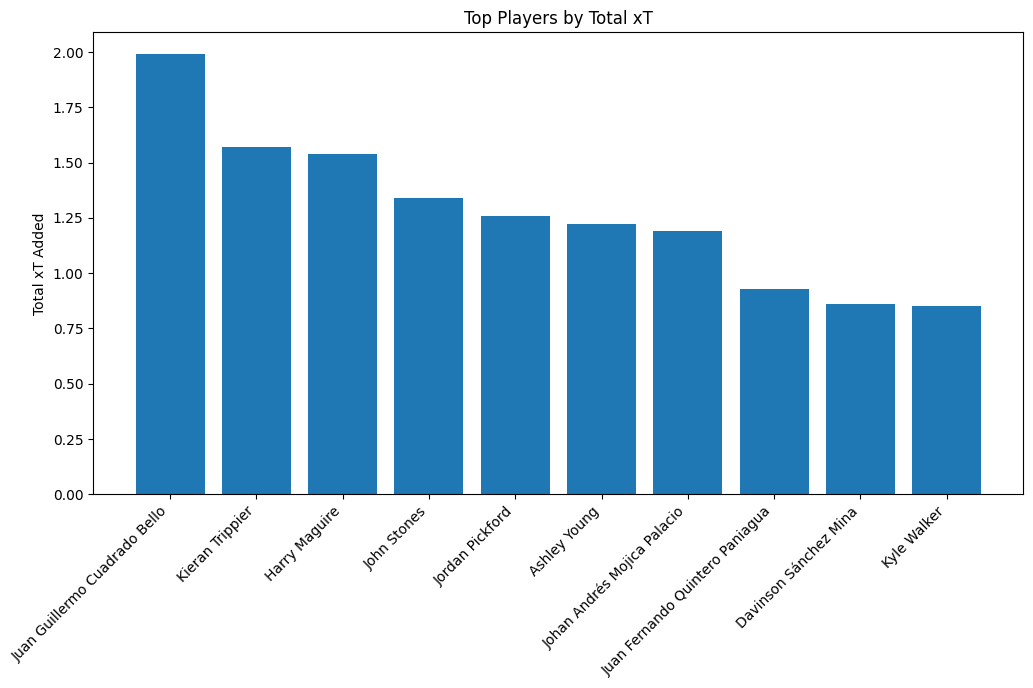

In [28]:
top_players = player_total_xt.head(10)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    top_players['player_name'],
    top_players['total_xT']
)

ax.set_title('Top Players by Total xT')
ax.set_ylabel('Total xT Added')

plt.xticks(rotation=45, ha='right')

plt.show()

In [29]:
# Create finer pitch bins
passes['x_bin'] = pd.cut(
    passes['x'],
    bins=12,
    labels=False
)

passes['y_bin'] = pd.cut(
    passes['y'],
    bins=8,
    labels=False
)

passes['end_x_bin'] = pd.cut(
    passes['end_x'],
    bins=12,
    labels=False
)

passes['end_y_bin'] = pd.cut(
    passes['end_y'],
    bins=8,
    labels=False
)

passes[
    [
        'x',
        'y',
        'x_bin',
        'y_bin'
    ]
].head()

,x,y,x_bin,y_bin
4,60.0,40.0,5,3
8,51.0,40.0,4,3
11,49.0,55.0,4,5
15,66.0,78.0,6,7
16,25.0,22.0,2,2


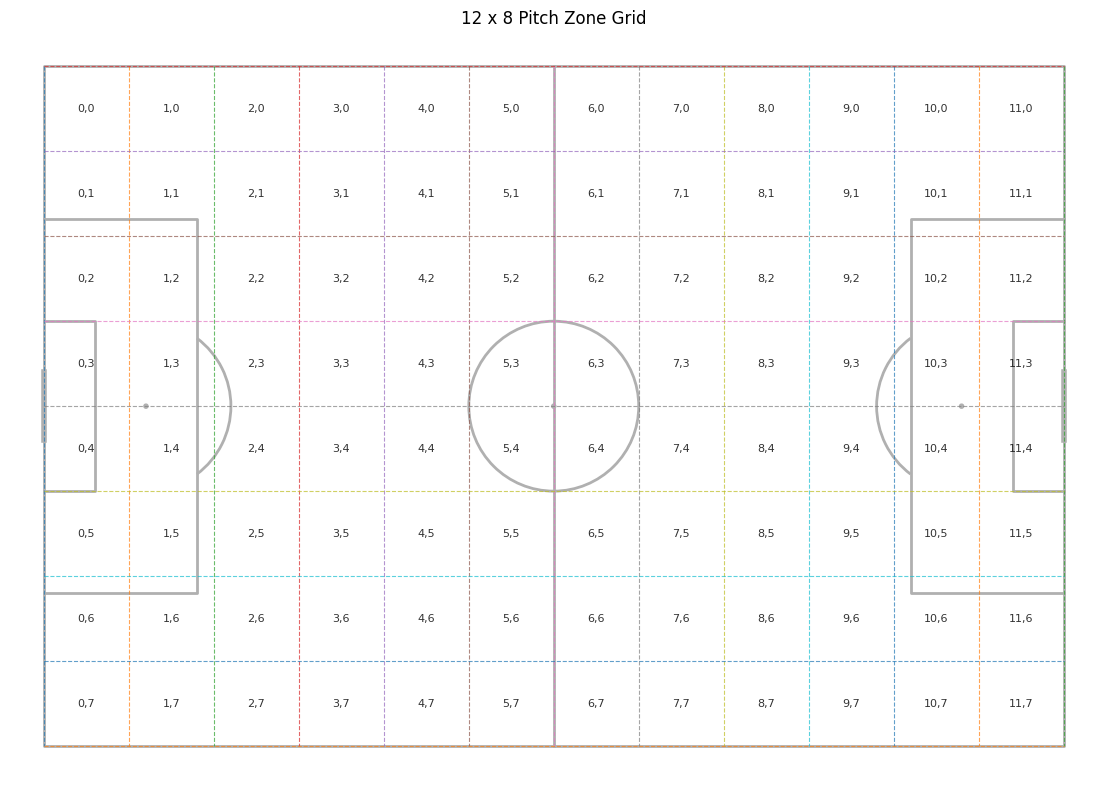

In [30]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import numpy as np

# Grid dimensions
x_bins = 12
y_bins = 8

pitch_length = 120
pitch_width = 80

x_edges = np.linspace(0, pitch_length, x_bins + 1)
y_edges = np.linspace(0, pitch_width, y_bins + 1)

pitch = Pitch(pitch_type='statsbomb')

fig, ax = pitch.draw(figsize=(12, 8))

# Draw vertical grid lines
for x in x_edges:
    ax.plot([x, x], [0, pitch_width], linestyle='--', linewidth=0.8, alpha=0.7)

# Draw horizontal grid lines
for y in y_edges:
    ax.plot([0, pitch_length], [y, y], linestyle='--', linewidth=0.8, alpha=0.7)

# Label each zone
for i in range(x_bins):
    for j in range(y_bins):
        x_center = (x_edges[i] + x_edges[i + 1]) / 2
        y_center = (y_edges[j] + y_edges[j + 1]) / 2
        
        ax.text(
            x_center,
            y_center,
            f'{i},{j}',
            ha='center',
            va='center',
            fontsize=8,
            alpha=0.8
        )

ax.set_title('12 x 8 Pitch Zone Grid')

plt.show()